In [274]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [275]:
dataset=pd.read_csv('/Users/gmabir/Desktop/untitled folder/travel insurance.csv')
dataset.head(5)

,Agency,Agency Type,Distribution Channel,Product Name,Claim,Duration,Destination,Net Sales,Commision (in value),Gender,Age
0,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,81
1,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,71
2,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,65,AUSTRALIA,-49.5,29.70,NaN,32
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,60,AUSTRALIA,-39.6,23.76,NaN,32
4,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,79,ITALY,-19.8,11.88,NaN,41


In [276]:
dataset.isnull().sum()

Agency                      0
Agency Type                 0
Distribution Channel        0
Product Name                0
Claim                       0
Duration                    0
Destination                 0
Net Sales                   0
Commision (in value)        0
Gender                  45107
Age                         0
dtype: int64

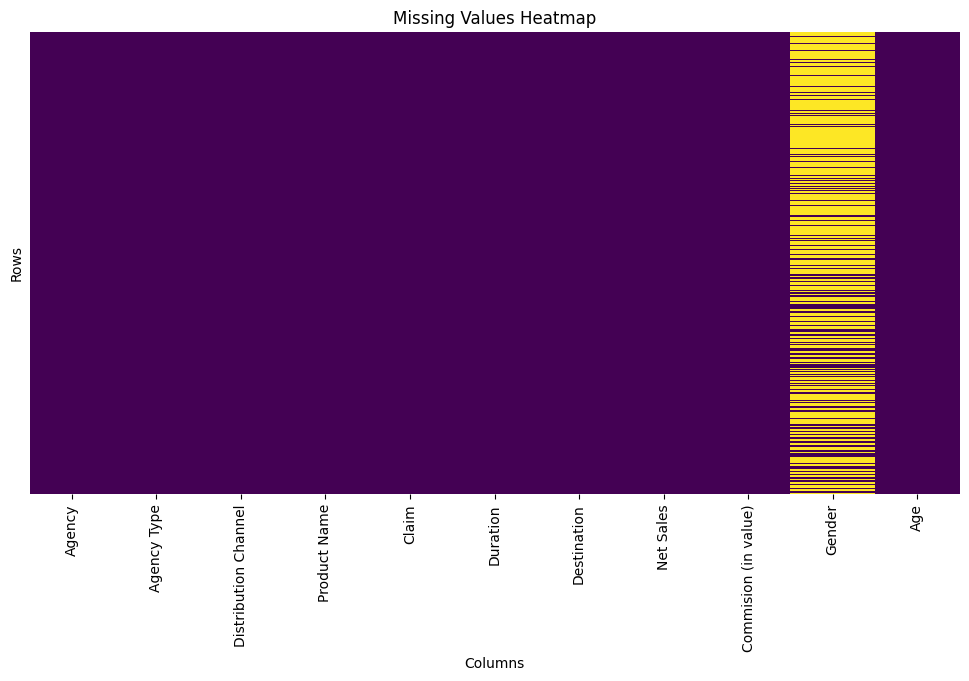

In [277]:

plt.figure(figsize=(12, 6))

sns.heatmap(
    dataset.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [278]:
dataset= dataset.drop(columns=['Gender'])  ###71% missingg data so it must be removed

In [279]:
dataset.isnull().sum()

Agency                  0
Agency Type             0
Distribution Channel    0
Product Name            0
Claim                   0
Duration                0
Destination             0
Net Sales               0
Commision (in value)    0
Age                     0
dtype: int64

In [280]:
dataset.select_dtypes(include=['object']).columns ##CATAGORICAL COLUMN CHECK

Index(['Agency', 'Agency Type', 'Distribution Channel', 'Product Name',
       'Claim', 'Destination'],
      dtype='object')

In [281]:
for col in dataset.select_dtypes(include=['object']).columns:    ##WHICH COLUMN HAVE CATAGORICS OF HOW MUCH
    print(col, dataset[col].unique())

Agency ['CBH' 'CWT' 'JZI' 'KML' 'EPX' 'C2B' 'JWT' 'RAB' 'SSI' 'ART' 'CSR' 'CCR'
 'ADM' 'LWC' 'TTW' 'TST']
Agency Type ['Travel Agency' 'Airlines']
Distribution Channel ['Offline' 'Online']
Product Name ['Comprehensive Plan' 'Rental Vehicle Excess Insurance' 'Value Plan'
 'Basic Plan' 'Premier Plan' '2 way Comprehensive Plan' 'Bronze Plan'
 'Silver Plan' 'Annual Silver Plan' 'Cancellation Plan'
 '1 way Comprehensive Plan' 'Ticket Protector' '24 Protect' 'Gold Plan'
 'Annual Gold Plan' 'Single Trip Travel Protect Silver'
 'Individual Comprehensive Plan' 'Spouse or Parents Comprehensive Plan'
 'Annual Travel Protect Silver' 'Single Trip Travel Protect Platinum'
 'Annual Travel Protect Gold' 'Single Trip Travel Protect Gold'
 'Annual Travel Protect Platinum' 'Child Comprehensive Plan'
 'Travel Cruise Protect' 'Travel Cruise Protect Family']
Claim ['No' 'Yes']
Destination ['MALAYSIA' 'AUSTRALIA' 'ITALY' 'UNITED STATES' 'THAILAND'
 "KOREA, DEMOCRATIC PEOPLE'S REPUBLIC OF" 'NORWAY' 'VIET NAM'

In [282]:
dataset['Claim'] = dataset['Claim'].map({'No': 0, 'Yes': 1})  # BINARY ENCODING

dataset['Agency Type'] = dataset['Agency Type'].map({'Travel Agency': 0, 'Airlines': 1})

dataset['Distribution Channel'] = dataset['Distribution Channel'].map({'Offline': 0, 'Online': 1})

In [283]:
dataset[['Claim', 'Agency Type', 'Distribution Channel']].isnull().sum()

Claim                   0
Agency Type             0
Distribution Channel    0
dtype: int64

In [284]:
dataset.columns

Index(['Agency', 'Agency Type', 'Distribution Channel', 'Product Name',
       'Claim', 'Duration', 'Destination', 'Net Sales', 'Commision (in value)',
       'Age'],
      dtype='object')

In [285]:
dataset = pd.read_csv('/Users/gmabir/Desktop/untitled folder/travel insurance.csv')

In [286]:
dataset[['Claim', 'Agency Type', 'Distribution Channel']].head()

,Claim,Agency Type,Distribution Channel
0,No,Travel Agency,Offline
1,No,Travel Agency,Offline
2,No,Travel Agency,Online
3,No,Travel Agency,Online
4,No,Travel Agency,Online


In [287]:
dataset = dataset.drop(columns=['Gender'])

In [288]:
dataset.select_dtypes(include=['object']).columns

Index(['Agency', 'Agency Type', 'Distribution Channel', 'Product Name',
       'Claim', 'Destination'],
      dtype='object')

In [289]:
dataset['Claim'] = dataset['Claim'].map({'No': 0, 'Yes': 1})
dataset['Agency Type'] = dataset['Agency Type'].map({'Travel Agency': 0, 'Airlines': 1})
dataset['Distribution Channel'] = dataset['Distribution Channel'].map({'Offline': 0, 'Online': 1})

In [290]:
dataset[['Claim', 'Agency Type', 'Distribution Channel']].head()

,Claim,Agency Type,Distribution Channel
0,0,0,0
1,0,0,0
2,0,0,1
3,0,0,1
4,0,0,1


In [291]:
dataset = pd.get_dummies(dataset, columns=['Agency', 'Product Name', 'Destination'])

In [292]:
dataset.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [293]:
dataset['Claim'].value_counts()

Claim
0    62399
1      927
Name: count, dtype: int64

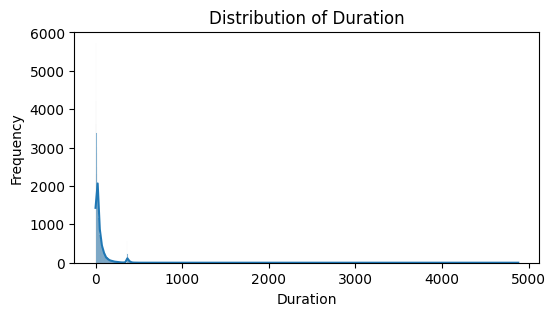

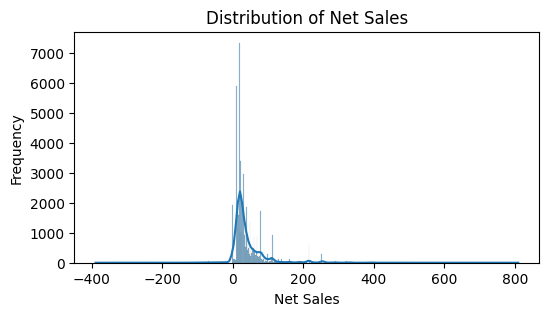

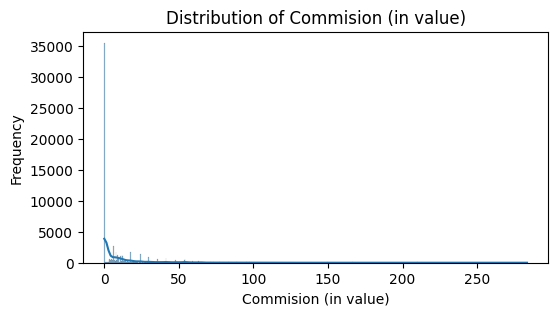

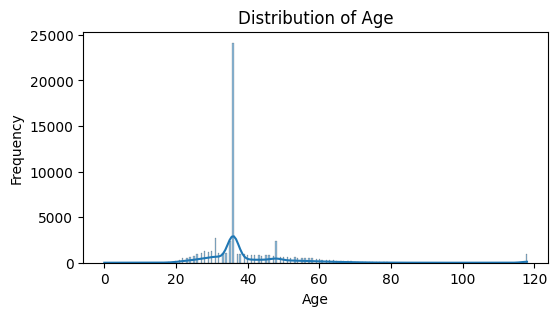

In [294]:
numerical_features = [
    "Duration",
    "Net Sales",
    "Commision (in value)",
    "Age"
]
for col in numerical_features:
    plt.figure(figsize=(6, 3))
    sns.histplot(dataset[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [295]:
#Imbalance
#group instances based on the classes in Claim variable
class_counts=dataset.groupby("Claim").size()

columns=['claim','count','percentage']
claim=[0,1]
count=list()
percentage=list()

#Calculate the percentage of each value of the Claim variable from total
for val in range(2):
    count.append(class_counts[val])
    percent=(class_counts[val]/63326)*100
    percentage.append(percent)

# Convert the calculated values into a dataframe
imbalance_df=pd.DataFrame(list(zip(claim,count,percentage)),columns=columns)
imbalance_df

,claim,count,percentage
0,0,62399,98.536146
1,1,927,1.463854


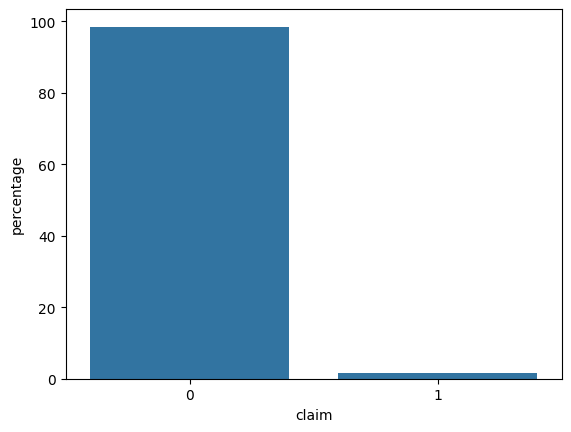

In [296]:
sns.barplot(data=imbalance_df,x=imbalance_df['claim'],y=imbalance_df['percentage'])
plt.show()

In [297]:
dataset[['Duration', 'Net Sales', 'Commision (in value)', 'Age']].describe()

,Duration,Net Sales,Commision (in value),Age
count,63326.000000,63326.000000,63326.000000,63326.000000
mean,49.317074,40.702018,9.809992,39.969981
std,101.791566,48.845637,19.804388,14.017010
min,-2.000000,-389.000000,0.000000,0.000000
25%,9.000000,18.000000,0.000000,35.000000
50%,22.000000,26.530000,0.000000,36.000000
75%,53.000000,48.000000,11.550000,43.000000
max,4881.000000,810.000000,283.500000,118.000000


In [298]:
dataset[['Duration', 'Net Sales', 'Commision (in value)', 'Age']].skew()

Duration                23.179617
Net Sales                3.272373
Commision (in value)     4.032269
Age                      2.987710
dtype: float64

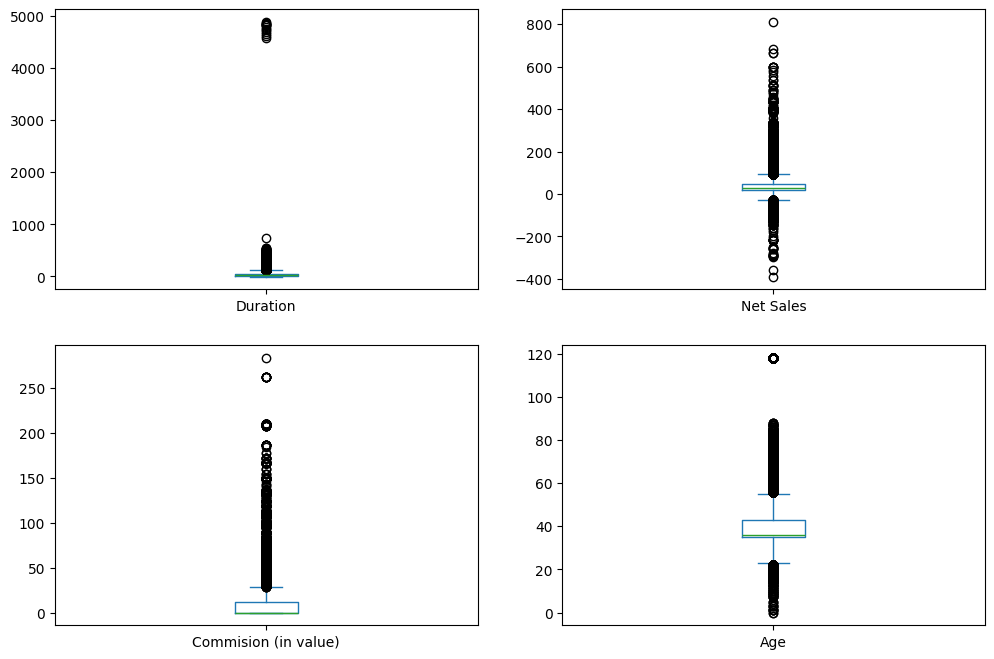

In [299]:
dataset[['Duration', 'Net Sales', 'Commision (in value)', 'Age']].plot(kind='box', subplots=True, layout=(2,2), figsize=(12,8))
plt.show()

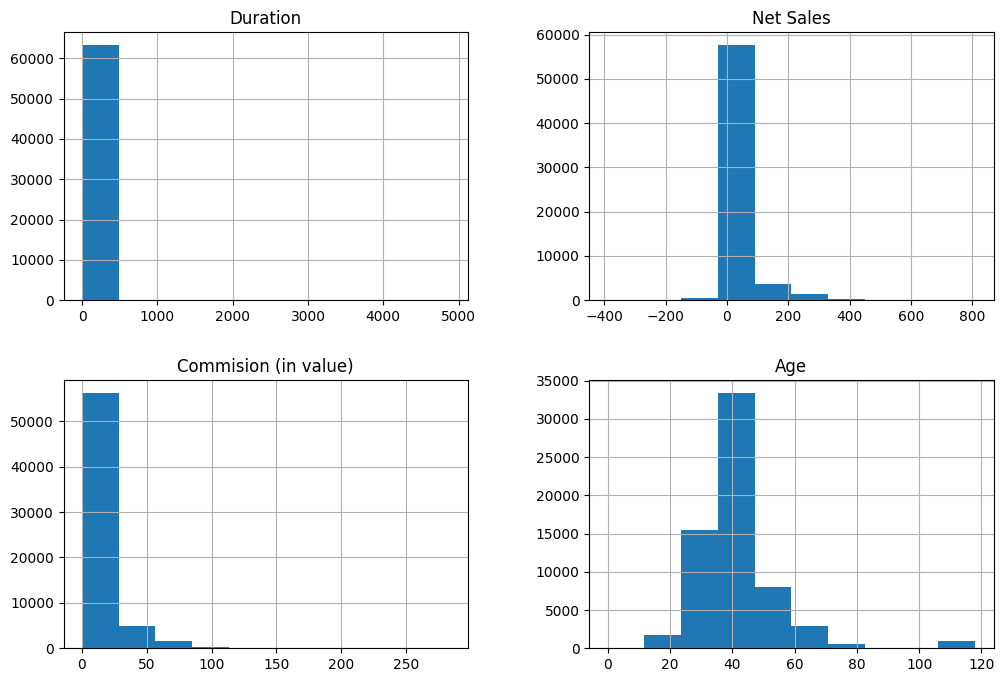

In [300]:
dataset[['Duration', 'Net Sales', 'Commision (in value)', 'Age']].hist(figsize=(12,8))
plt.show()

In [301]:
dataset[['Duration', 'Net Sales', 'Commision (in value)', 'Age', 'Claim']].corr()

,Duration,Net Sales,Commision (in value),Age,Claim
Duration,1.000000,0.429235,0.344772,0.002468,0.073607
Net Sales,0.429235,1.000000,0.651315,0.037756,0.133931
Commision (in value),0.344772,0.651315,1.000000,0.118348,0.098696
Age,0.002468,0.037756,0.118348,1.000000,-0.011614
Claim,0.073607,0.133931,0.098696,-0.011614,1.000000


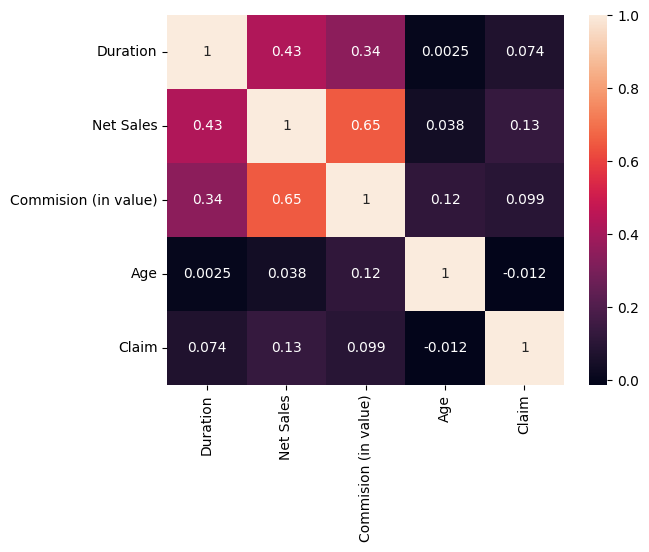

In [ ]:
corr = dataset[['Duration', 'Net Sales', 'Commision (in value)', 'Age', 'Claim']].corr()

sns.heatmap(corr, annot=True)
plt.show()          ##threshold<.80

In [303]:
X = dataset.drop('Claim', axis=1)
y = dataset['Claim']

In [304]:
X.shape, y.shape

((63326, 197), (63326,))

Spliting Data

In [305]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [306]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((50660, 197), (12666, 197), (50660,), (12666,))

In [307]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [1]:
print(X_test)

NameError: name 'X_test' is not defined

Logistic regration


In [308]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",     ##because the data is highly imbalenced
    max_iter=1000,
    random_state=1
)

logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,1
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [309]:
y_pred = logistic_model.predict(X_test)

In [310]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

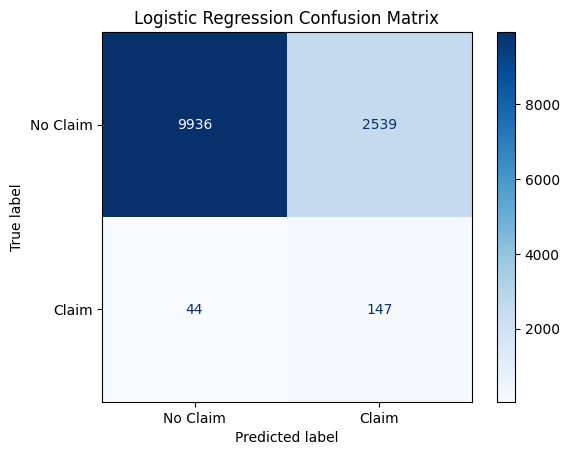

In [311]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["No Claim", "Claim"]
).plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [312]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7960682141165325
Precision: 0.05472822040208489
Recall: 0.7696335078534031
F1-score: 0.10218978102189781


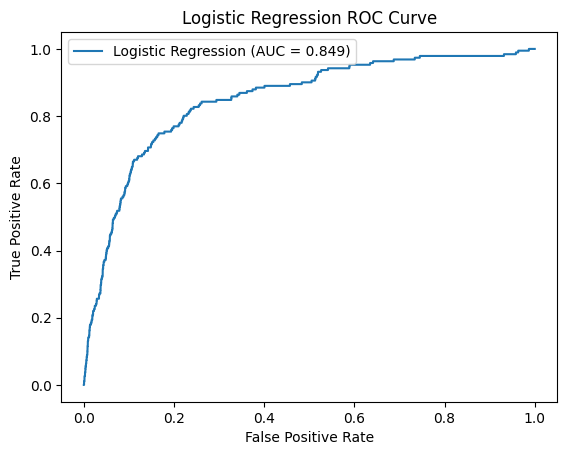

ROC-AUC: 0.8494887156511977


In [313]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC:", roc_auc)

---------KN-------

In [314]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [315]:
y_pred_knn = knn_model.predict(X_test)

print(y_pred_knn)

[0 0 0 ... 0 0 0]


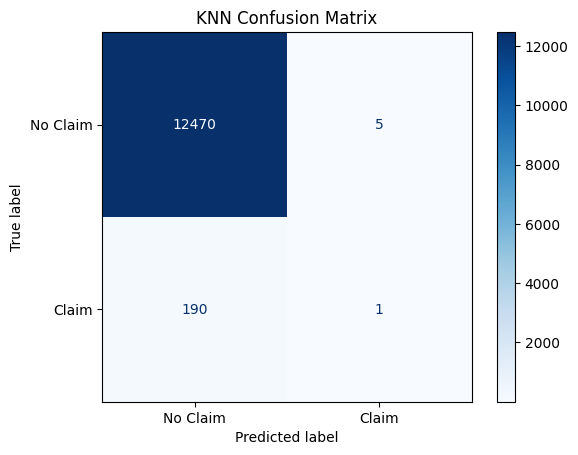

In [316]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)

ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["No Claim", "Claim"]
).plot(cmap="Blues")

plt.title("KNN Confusion Matrix")
plt.show()


In [317]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)
print("KNN Precision:", precision_knn)
print("KNN Recall:", recall_knn)
print("KNN F1-score:", f1_knn)


KNN Accuracy: 0.9846044528659403
KNN Precision: 0.16666666666666666
KNN Recall: 0.005235602094240838
KNN F1-score: 0.01015228426395939


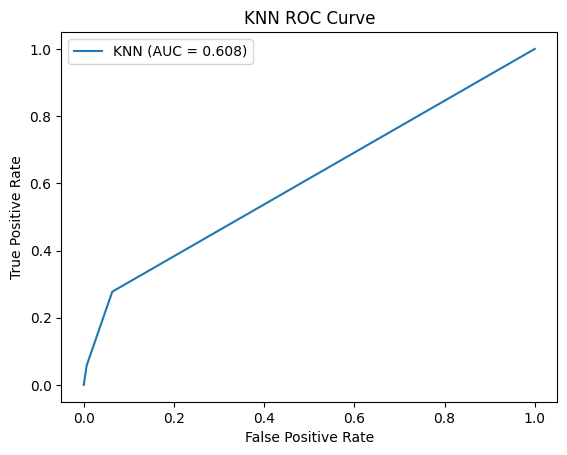

KNN ROC-AUC: 0.6081538994218804


In [318]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"KNN (AUC = {roc_auc_knn:.3f})"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()

print("KNN ROC-AUC:", roc_auc_knn)

--------DecisionTree--------

In [319]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(random_state=1)
decision_tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [320]:
y_pred_tree = decision_tree_model.predict(X_test)

print(y_pred_tree)

[0 0 0 ... 0 0 0]


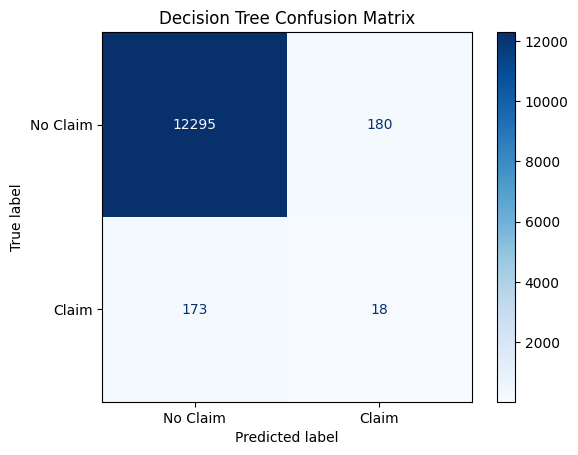

In [321]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_tree = confusion_matrix(y_test, y_pred_tree)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["No Claim", "Claim"]
).plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [322]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)
print("Decision Tree Precision:", precision_tree)
print("Decision Tree Recall:", recall_tree)
print("Decision Tree F1-score:", f1_tree)

Decision Tree Accuracy: 0.9721301121111637
Decision Tree Precision: 0.09090909090909091
Decision Tree Recall: 0.09424083769633508
Decision Tree F1-score: 0.09254498714652956


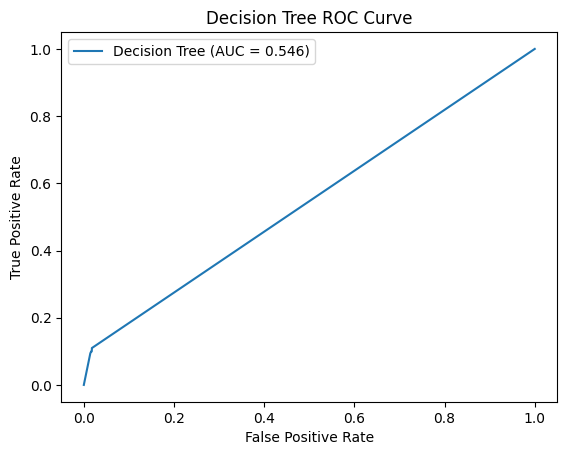

Decision Tree ROC-AUC: 0.5459654387308649


In [323]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, y_prob_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {roc_auc_tree:.3f})"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

print("Decision Tree ROC-AUC:", roc_auc_tree)

_______NURAL NETWORK__________

In [ ]:
from sklearn.neural_network import MLPClassifier

neural_network_model= MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',    ##optimized algorithm 
    #alpha=0.01,                 # Stronger L2 regularization against overfitting
    #learning_rate_init=0.001,
    max_iter=1000,
    #early_stopping=True,        # Avoid over-training on majority noise
    random_state=1
)

neural_network_model.fit(X_train, y_train)  ##pytorch or tensoflow weighted cross-entropy loss

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,1


In [325]:
y_pred_nn = neural_network_model.predict(X_test)

print(y_pred_nn[:10])

[0 0 0 0 0 0 0 0 0 0]


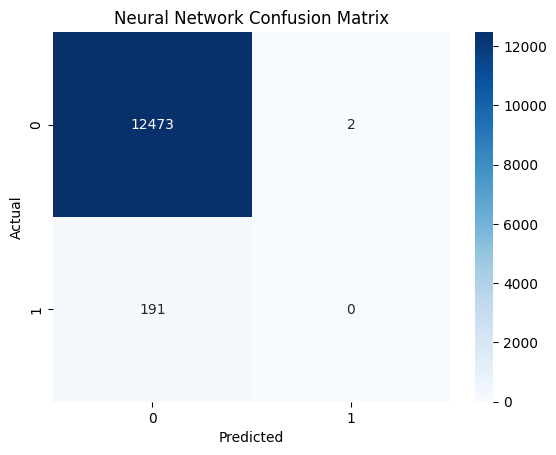

In [326]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nn = confusion_matrix(y_test, y_pred_nn)

sns.heatmap(cm_nn, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")
plt.show()

In [327]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)

print("Neural Network Accuracy:", accuracy_nn)
print("Neural Network Precision:", precision_nn)
print("Neural Network Recall:", recall_nn)
print("Neural Network F1-score:", f1_nn)

Neural Network Accuracy: 0.9847623559134692
Neural Network Precision: 0.0
Neural Network Recall: 0.0
Neural Network F1-score: 0.0


In [328]:
from sklearn.metrics import roc_auc_score

y_prob_nn = neural_network_model.predict_proba(X_test)[:, 1]

roc_auc_nn = roc_auc_score(y_test, y_prob_nn)

print("Neural Network ROC-AUC:", roc_auc_nn)

Neural Network ROC-AUC: 0.8314371150678319


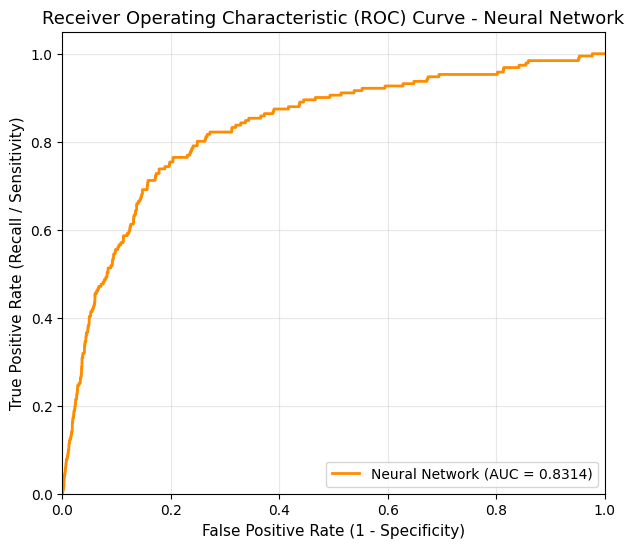

In [346]:
y_prob_nn = neural_network_model.predict_proba(X_test)[:, 1]

# 2. Compute ROC curve values and ROC-AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nn)
roc_auc_nn = roc_auc_score(y_test, y_prob_nn)

# 3. Plot the ROC Curve without the diagonal reference line
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Neural Network (AUC = {roc_auc_nn:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve - Neural Network', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [329]:
# RMSE and complete model comparison

from sklearn.metrics import mean_squared_error

# Calculate RMSE using predicted probabilities
rmse_logistic = np.sqrt(
    mean_squared_error(y_test, y_prob)
)

rmse_knn = np.sqrt(
    mean_squared_error(y_test, y_prob_knn)
)

rmse_tree = np.sqrt(
    mean_squared_error(y_test, y_prob_tree)
)

rmse_nn = np.sqrt(
    mean_squared_error(y_test, y_prob_nn)
)

# Create a comparison table using the actual calculated results
comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Neural Network"
    ],

    "Accuracy": [
        accuracy,
        accuracy_knn,
        accuracy_tree,
        accuracy_nn
    ],

    "Precision": [
        precision,
        precision_knn,
        precision_tree,
        precision_nn
    ],

    "Recall": [
        recall,
        recall_knn,
        recall_tree,
        recall_nn
    ],

    "F1-score": [
        f1,
        f1_knn,
        f1_tree,
        f1_nn
    ],

    "ROC-AUC": [
        roc_auc,
        roc_auc_knn,
        roc_auc_tree,
        roc_auc_nn
    ],

    "RMSE": [
        rmse_logistic,
        rmse_knn,
        rmse_tree,
        rmse_nn
    ]
})

# Round the values for easier reading
comparison_table = comparison_table.round(4)

# Display the complete comparison
print("Complete Model Comparison:")
display(comparison_table)

Complete Model Comparison:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,RMSE
0,Logistic Regression,0.7961,0.0547,0.7696,0.1022,0.8495,0.4031
1,KNN,0.9846,0.1667,0.0052,0.0102,0.6082,0.1291
2,Decision Tree,0.9721,0.0909,0.0942,0.0925,0.5460,0.1684
3,Neural Network,0.9848,0.0000,0.0000,0.0000,0.8314,0.1203


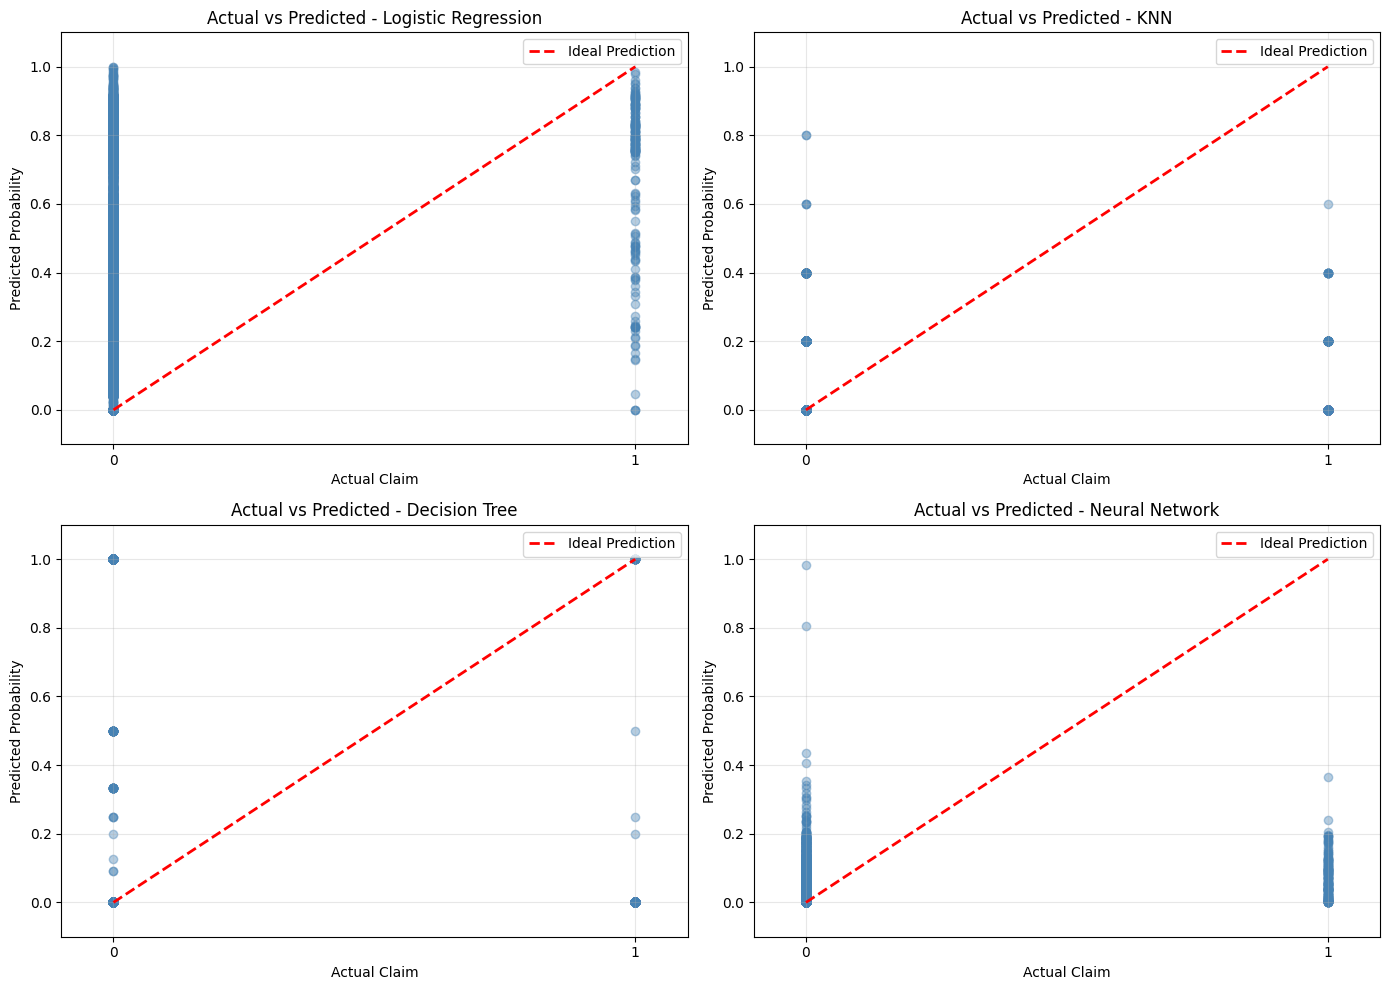

In [330]:
import matplotlib.pyplot as plt
import numpy as np

# Store model names and predicted probabilities
model_predictions = {
    "Logistic Regression": y_prob,
    "KNN": y_prob_knn,
    "Decision Tree": y_prob_tree,
    "Neural Network": y_prob_nn
}

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Flatten the axes so we can loop through them easily
axes = axes.ravel()

# Plot each model
for ax, (model_name, predictions) in zip(axes, model_predictions.items()):

    # Plot actual values against predicted probabilities
    ax.scatter(
        y_test,
        predictions,
        alpha=0.4,
        color="steelblue"
    )

    # Ideal prediction line
    ax.plot(
        [0, 1],
        [0, 1],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Ideal Prediction"
    )

    # Set plot labels and title
    ax.set_title(f"Actual vs Predicted - {model_name}")
    ax.set_xlabel("Actual Claim")
    ax.set_ylabel("Predicted Probability")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xticks([0, 1])
    ax.grid(True, alpha=0.3)
    ax.legend()

# Adjust spacing
plt.tight_layout()

# Display the plots
plt.show()

Highest accuracy: Neural Network — 0.9848
Highest ROC-AUC: Logistic Regression — 0.8495
Highest recall: Logistic Regression — 0.7696
Best model for identifying positive cases: Logistic Regression
Most misleading metric: Accuracy, because the dataset is imbalanced

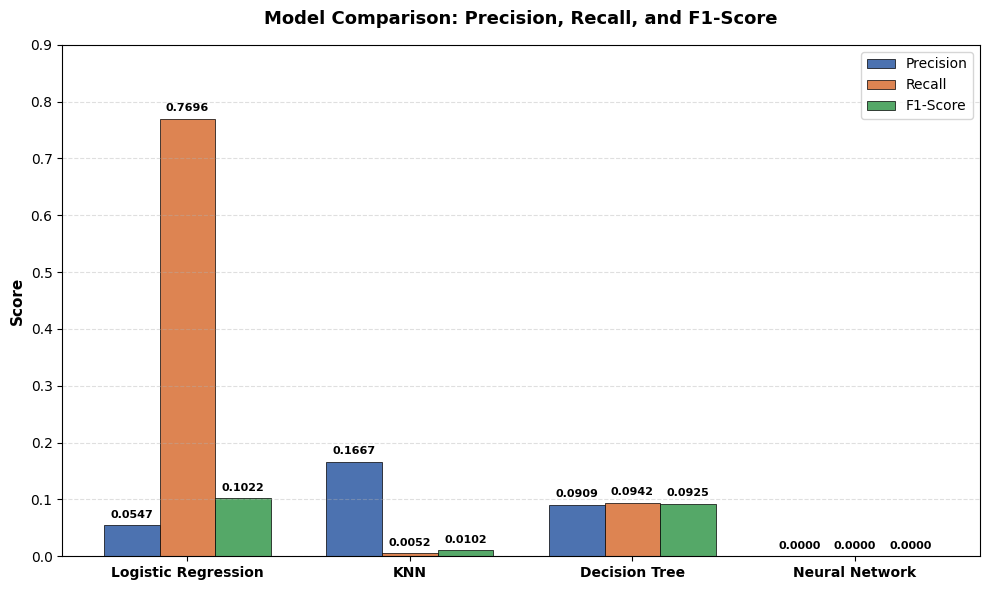

In [347]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and evaluated metrics
models = ["Logistic Regression", "KNN", "Decision Tree", "Neural Network"]
precision = [0.0547, 0.1667, 0.0909, 0.0000]
recall = [0.7696, 0.0052, 0.0942, 0.0000]
f1 = [0.1022, 0.0102, 0.0925, 0.0000]

# Bar positioning setup
x = np.arange(len(models))
bar_width = 0.25

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(
    x - bar_width,
    precision,
    bar_width,
    label="Precision",
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)
rects2 = ax.bar(
    x,
    recall,
    bar_width,
    label="Recall",
    color="#DD8452",
    edgecolor="black",
    linewidth=0.5,
)
rects3 = ax.bar(
    x + bar_width,
    f1,
    bar_width,
    label="F1-Score",
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)


# Add value labels on top of bars
def autolabel(rects):
  for rect in rects:
    h = rect.get_height()
    ax.annotate(
        f"{h:.4f}",
        xy=(rect.get_x() + rect.get_width() / 2, h),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
    )


autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Chart styling and details
ax.set_ylabel("Score", fontsize=11, fontweight="bold")
ax.set_title(
    "Model Comparison: Precision, Recall, and F1-Score",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10, fontweight="bold")
ax.set_ylim(0, 0.90)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="upper right", fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

In [331]:
import pandas as pd

df = pd.read_csv("/Users/gmabir/Desktop/untitled folder/travel insurance.csv")

df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Claim,Duration,Destination,Net Sales,Commision (in value),Gender,Age
0,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,81
1,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,71
2,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,65,AUSTRALIA,-49.5,29.70,NaN,32
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,60,AUSTRALIA,-39.6,23.76,NaN,32
4,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,79,ITALY,-19.8,11.88,NaN,41


In [332]:
df.shape

(63326, 11)

In [333]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63326 entries, 0 to 63325
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                63326 non-null  object 
 1   Agency Type           63326 non-null  object 
 2   Distribution Channel  63326 non-null  object 
 3   Product Name          63326 non-null  object 
 4   Claim                 63326 non-null  object 
 5   Duration              63326 non-null  int64  
 6   Destination           63326 non-null  object 
 7   Net Sales             63326 non-null  float64
 8   Commision (in value)  63326 non-null  float64
 9   Gender                18219 non-null  object 
 10  Age                   63326 non-null  int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 5.3+ MB


In [334]:
df.columns

Index(['Agency', 'Agency Type', 'Distribution Channel', 'Product Name',
       'Claim', 'Duration', 'Destination', 'Net Sales', 'Commision (in value)',
       'Gender', 'Age'],
      dtype='object')

In [335]:
X = df.drop(columns=["Claim"])

In [336]:
X["Gender"] = X["Gender"].fillna("Unknown")


In [337]:
X_encoded = pd.get_dummies(X, drop_first=True)


In [338]:
print("Dimensão dos dados preparados:", X_encoded.shape)
X_encoded.head()

Dimensão dos dados preparados: (63326, 196)


,Duration,Net Sales,Commision (in value),Age,Agency_ART,Agency_C2B,Agency_CBH,Agency_CCR,Agency_CSR,Agency_CWT,...,Destination_URUGUAY,Destination_UZBEKISTAN,Destination_VANUATU,Destination_VENEZUELA,Destination_VIET NAM,"Destination_VIRGIN ISLANDS, U.S.",Destination_ZAMBIA,Destination_ZIMBABWE,Gender_M,Gender_Unknown
0,186,-29.0,9.57,81,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,186,-29.0,9.57,71,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,65,-49.5,29.70,32,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
3,60,-39.6,23.76,32,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,79,-19.8,11.88,41,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [339]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (63326, 196)


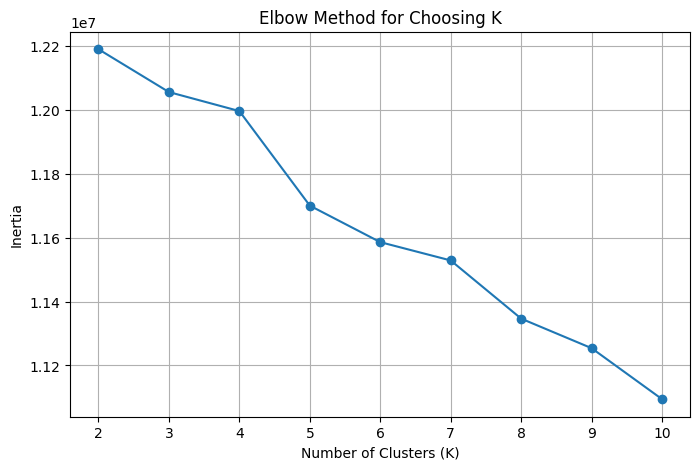

In [340]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [341]:
kmeans = KMeans(n_clusters=5, random_state=1, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df["Cluster"].value_counts().sort_index()

Cluster
0    13271
1      331
2    32902
3     8619
4     8203
Name: count, dtype: int64

In [342]:
cluster_profile = df.groupby("Cluster")[
    ["Duration", "Net Sales", "Commision (in value)", "Age"]
].mean().round(2)

cluster_profile

,Duration,Net Sales,Commision (in value),Age
Cluster,,,,
0,42.71,42.41,0.00,37.42
1,30.36,28.69,10.55,60.31
2,39.28,30.55,9.24,38.52
3,113.96,83.71,24.29,37.88
4,33.12,33.96,12.73,51.27


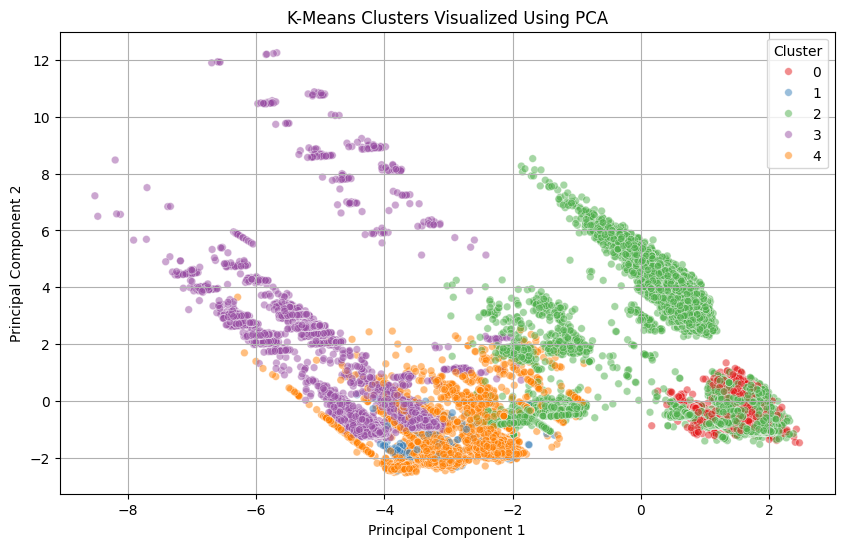

In [343]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=1)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["Cluster"],
    palette="Set1",
    alpha=0.5,
    s=30
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized Using PCA")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()